# Análisis exploratorio de datos

## Definición
__[Wikipedia](https://en.wikipedia.org/wiki/Exploratory_data_analysis)__

Un enfoque para el análisis de un conjunto de datos que tiene el objetivo de resumir sus principales características, frecuentemente apoyándose en visualizaciones (gráficas).

## Beneficios

- Profundizar la comprensión del dominio del problema.

- Identificar la naturaleza de los datos (**cuantitativa** - contínua, discreta; **cronológica**; **cualitativa** - nominal, categórica)

- Identificar el nivel de calidad de los datos (faltantes, atípicos)

- Identificar correlaciones entre datos que puedan ser la base para la formulación de hipótesis sobre relaciones causa efecto. (Con la menor cantidad de variables posible)


## Proceso

- Análisis unidimensional

- Análisis multidimensional

- Reducción de la dimensionalidad (factor analysis)?

- Segmentación/clustering de datos (identificar grupos/clusters de observaciones similares)?

## Técnicas

### Visualización

- Tendencia central y dispersión - Gráfico de distribución
- Comparación - Gráfico de barras
- Relación - lineas, scatter plots
- Composición/Proporción - Tortas, barras apiladas

Revisar **choosing-a-good-chart-09.pdf**

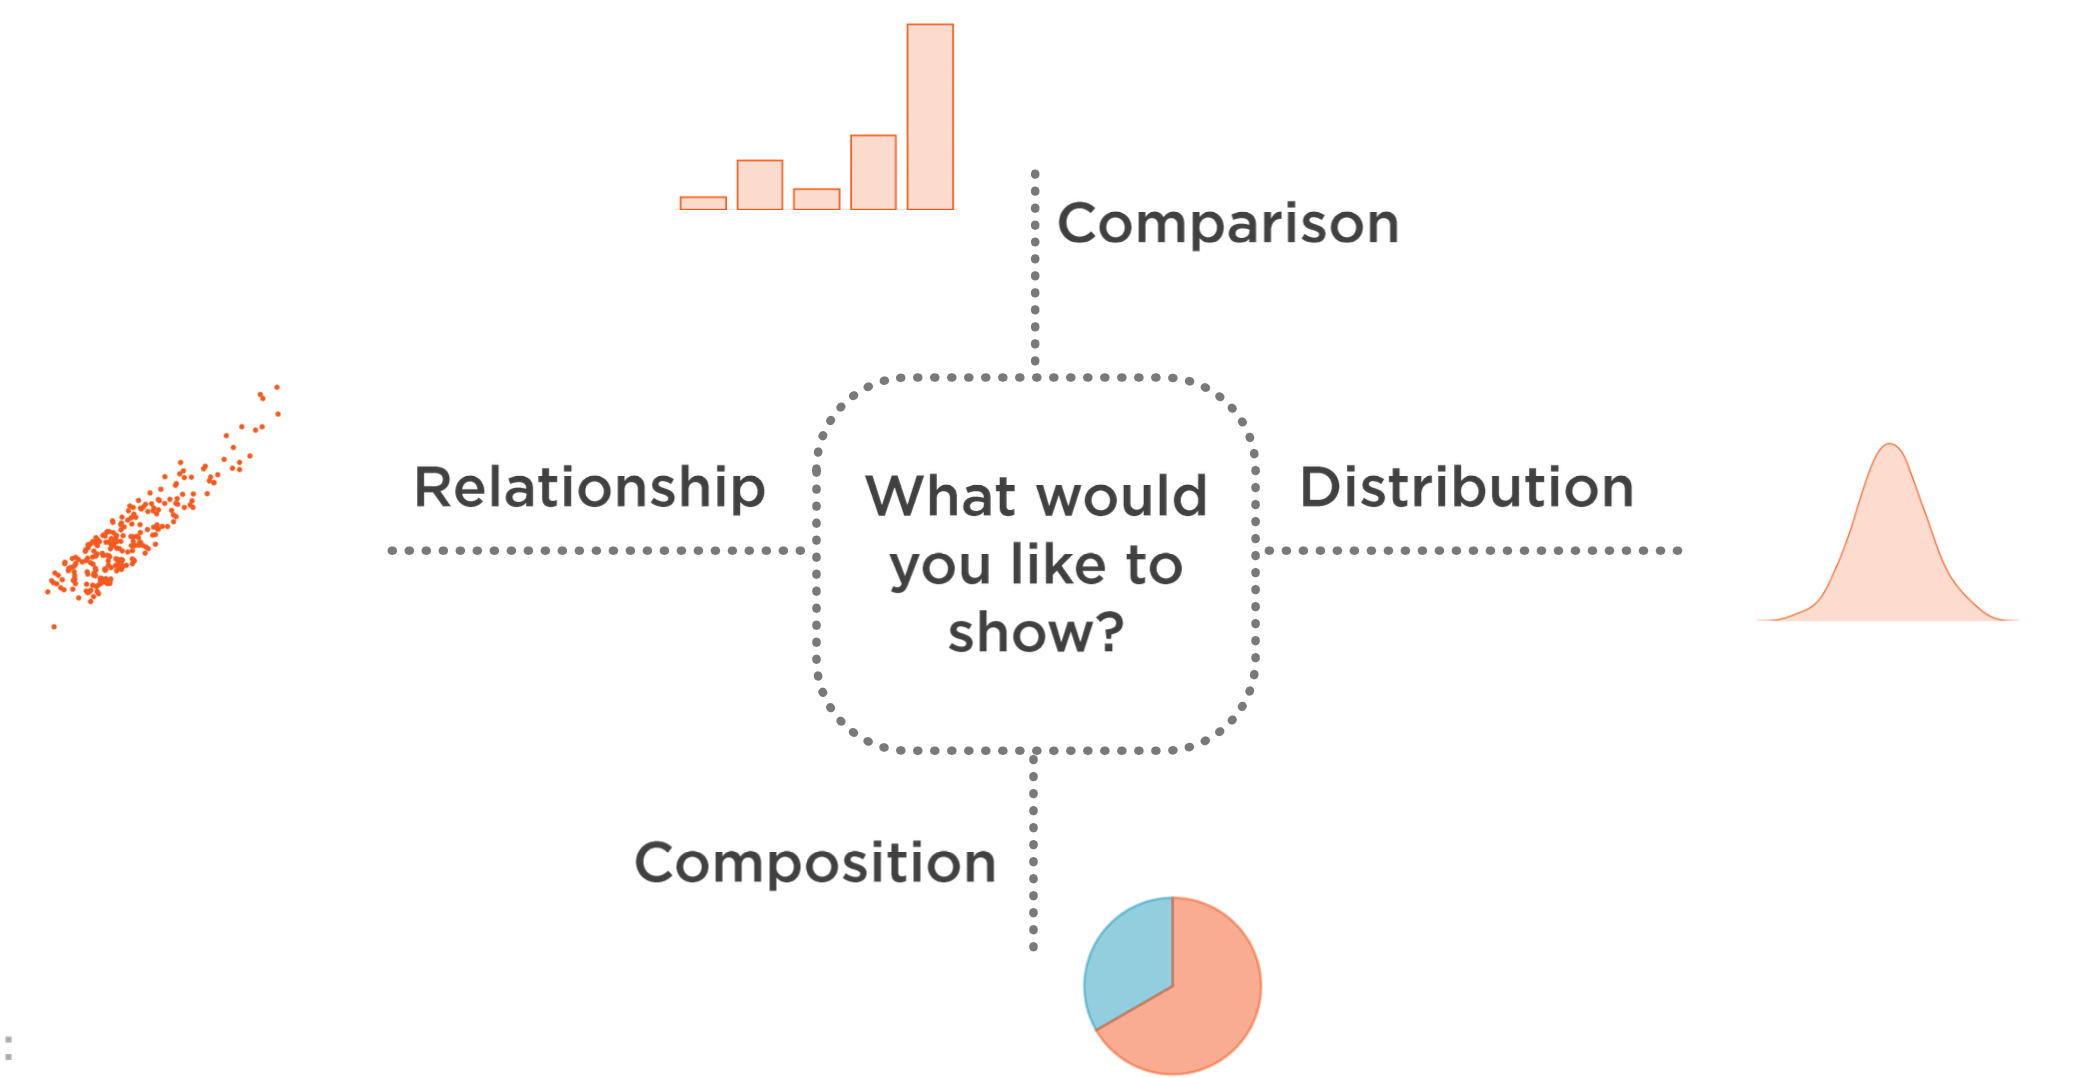

# Indicadores descriptivos

## Tendencia central y dispersión

- Media.
- Mediana.
- Quantiles. Valores que dividen las observaciones en partes iguales. Los quartiles (3) y deciles (9) son los más comunes.


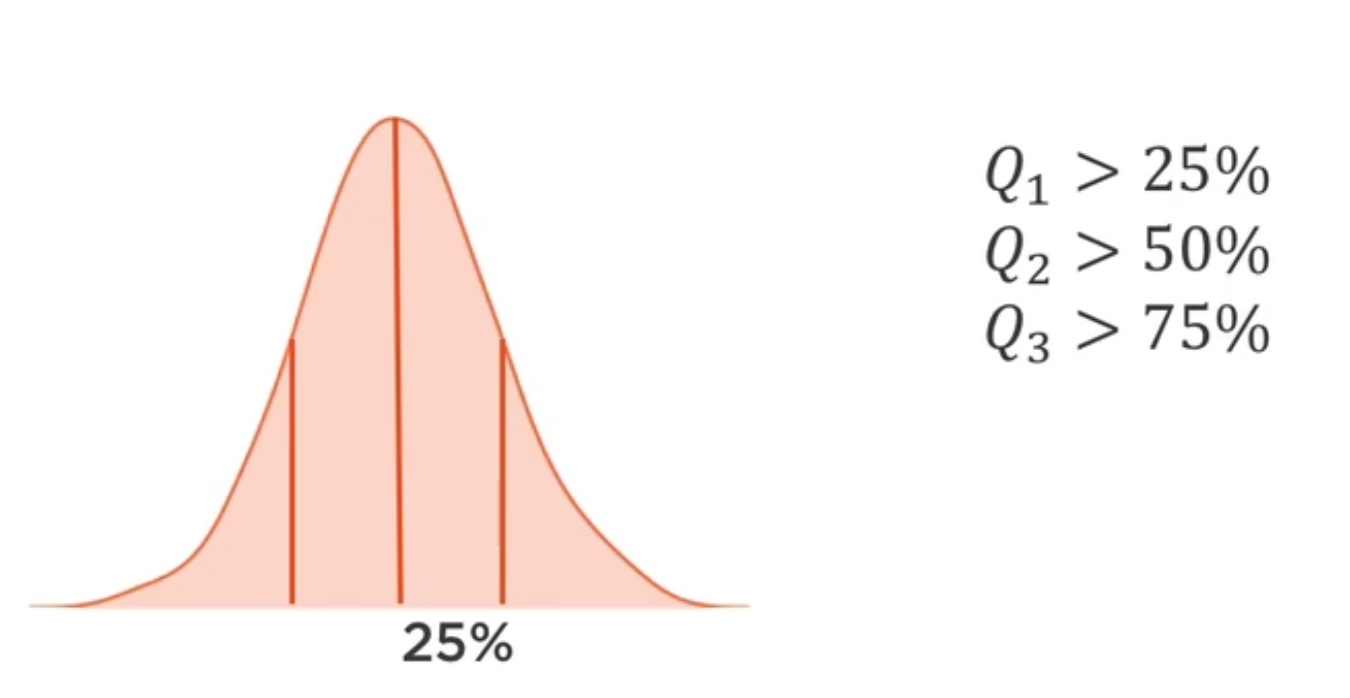

- Varianza, desviación estándar

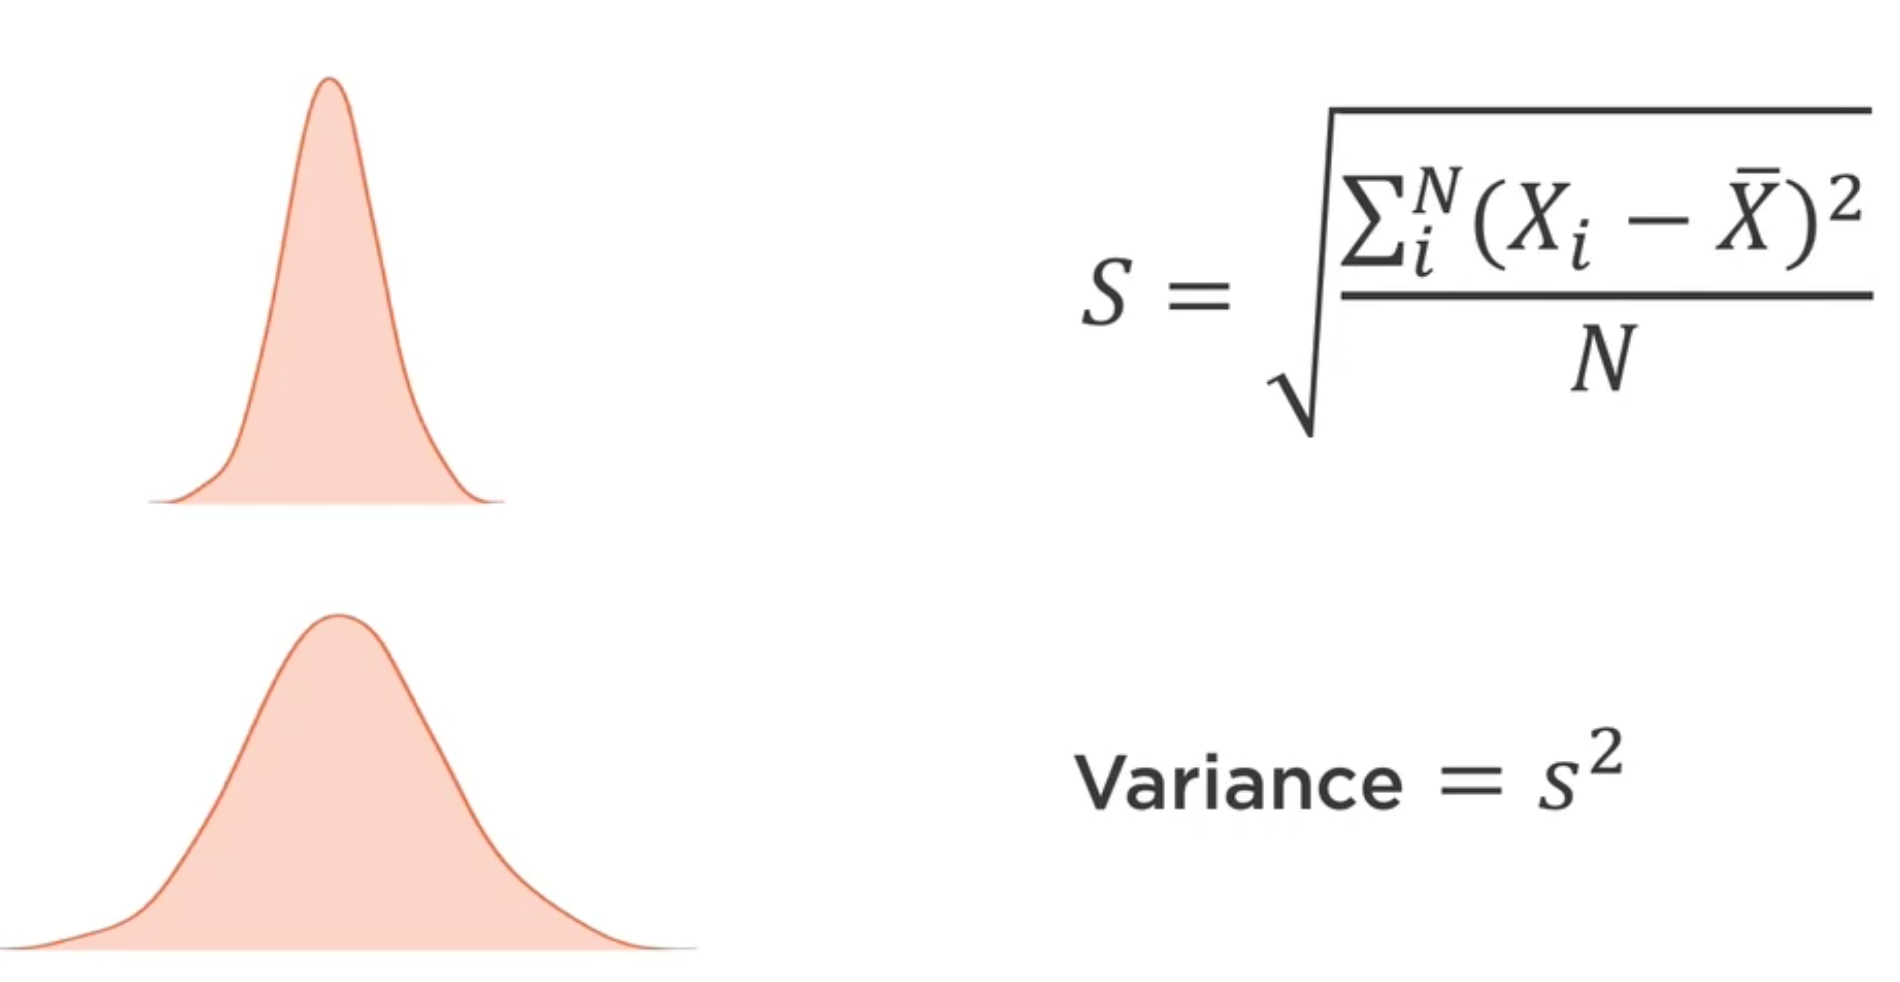

- Valores atípicos

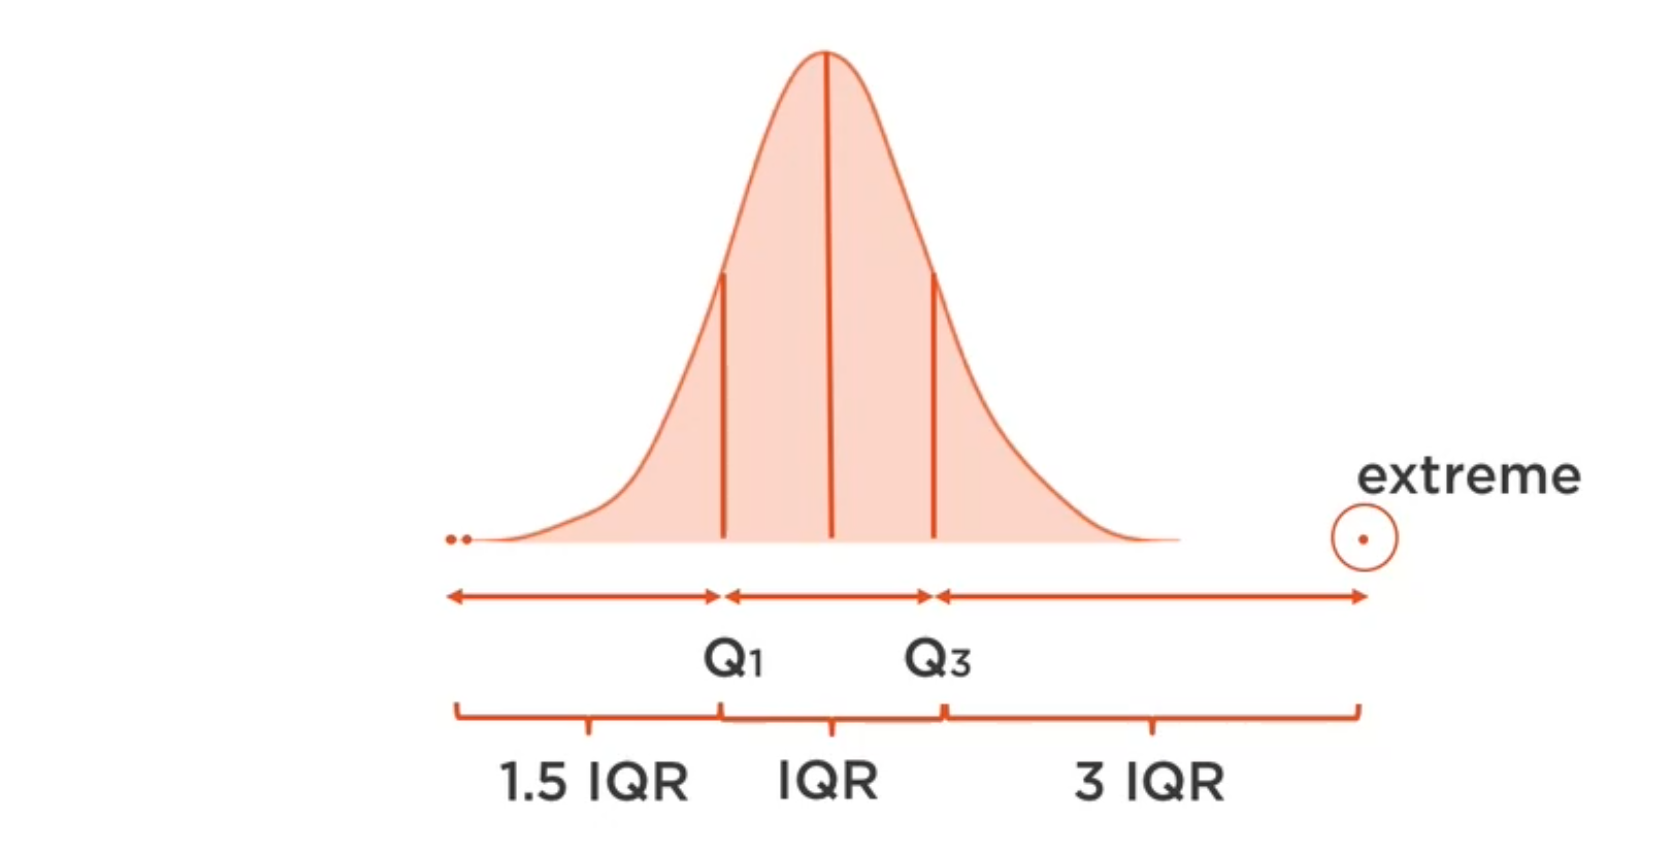

Dependiendo del escenario se pueden preservar o eliminar los valores atípicos. (Ejemplos?)

- Asimetría (skweness). Grado de simetría de la distribución.

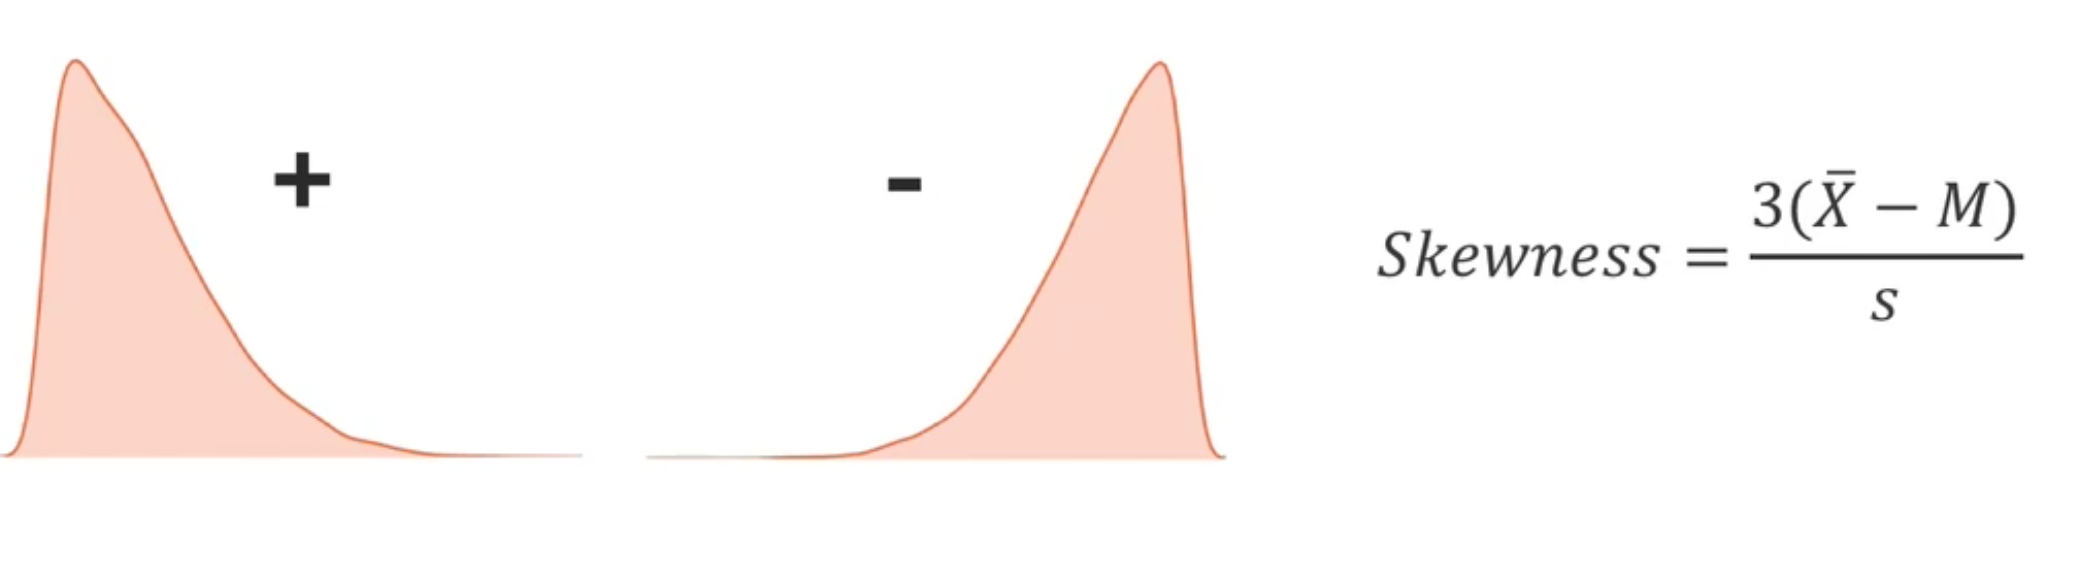




## Carga de datos
__[Fuente de datos](https://archive.ics.uci.edu/ml/datasets/Forest+Fires)__


1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec"
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3
7. DC - DC index from the FWI system: 7.9 to 860.6
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40
12. rain - outside rain in mm/m2 : 0.0 to 6.4
13. area - the burned area of the forest (in ha): 0.00 to 1090.84
(this output variable is very skewed towards 0.0, thus it may make
sense to model with the logarithm transform)

In [30]:
import polars as pl

In [31]:
forestfires = pl.read_csv("forestfires.csv"
    , schema_overrides={
        "area": pl.Float64
    }
)
forestfires

X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
i64,i64,str,str,f64,f64,f64,f64,f64,i64,f64,f64,f64
7,5,"""mar""","""fri""",86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
7,4,"""oct""","""tue""",90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
7,4,"""oct""","""sat""",90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
8,6,"""mar""","""fri""",91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
8,6,"""mar""","""sun""",89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
4,3,"""aug""","""sun""",81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
2,4,"""aug""","""sun""",81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
7,4,"""aug""","""sun""",81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16


## Tendencia central

In [32]:
forestfires.select(pl.col('temp').mean())

temp
f64
18.889168


In [33]:
forestfires.select(pl.col('temp').median())

temp
f64
19.3


## Dispersión

In [34]:
forestfires.select(pl.col('temp').std())

temp
f64
5.806625


## Forma

In [35]:
forestfires.select(pl.col('temp').skew())

temp
f64
-0.330211


## Visualización

Los datos de un DataFrame de Polars se pueden visualizar utilizando [diferentes librerías de visualización](https://docs.pola.rs/user-guide/misc/visualization/).

Polars no viene incluye funcionalidad para generar visualizaciones; desde la versión 1.6.0, [la librearía de visualización por defecto es Altair](https://docs.pola.rs/api/python/stable/reference/dataframe/plot.html) (pero esto puede cambiar en el futuro).

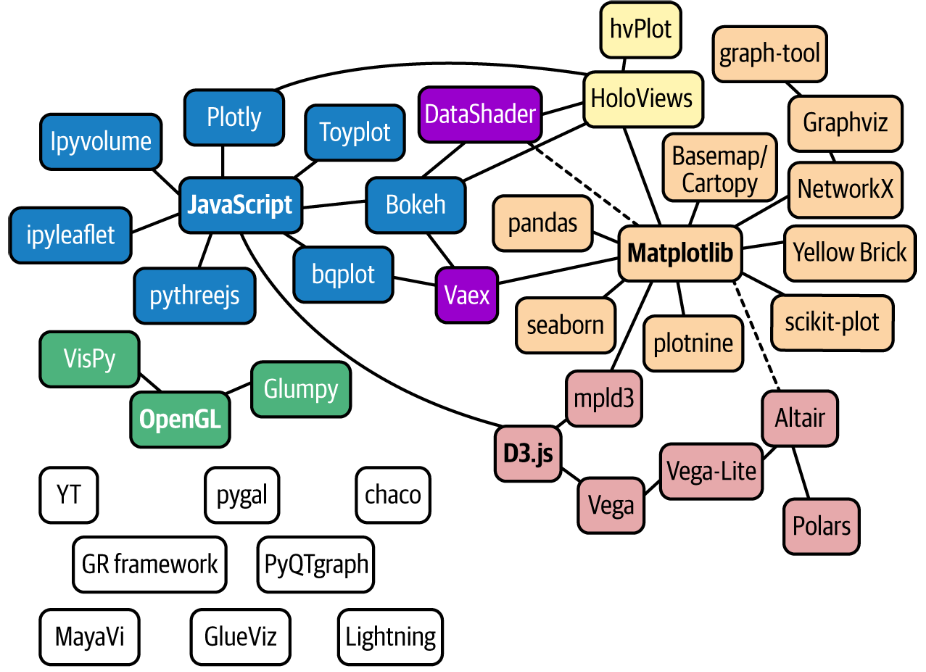

## Gráficos de distribución

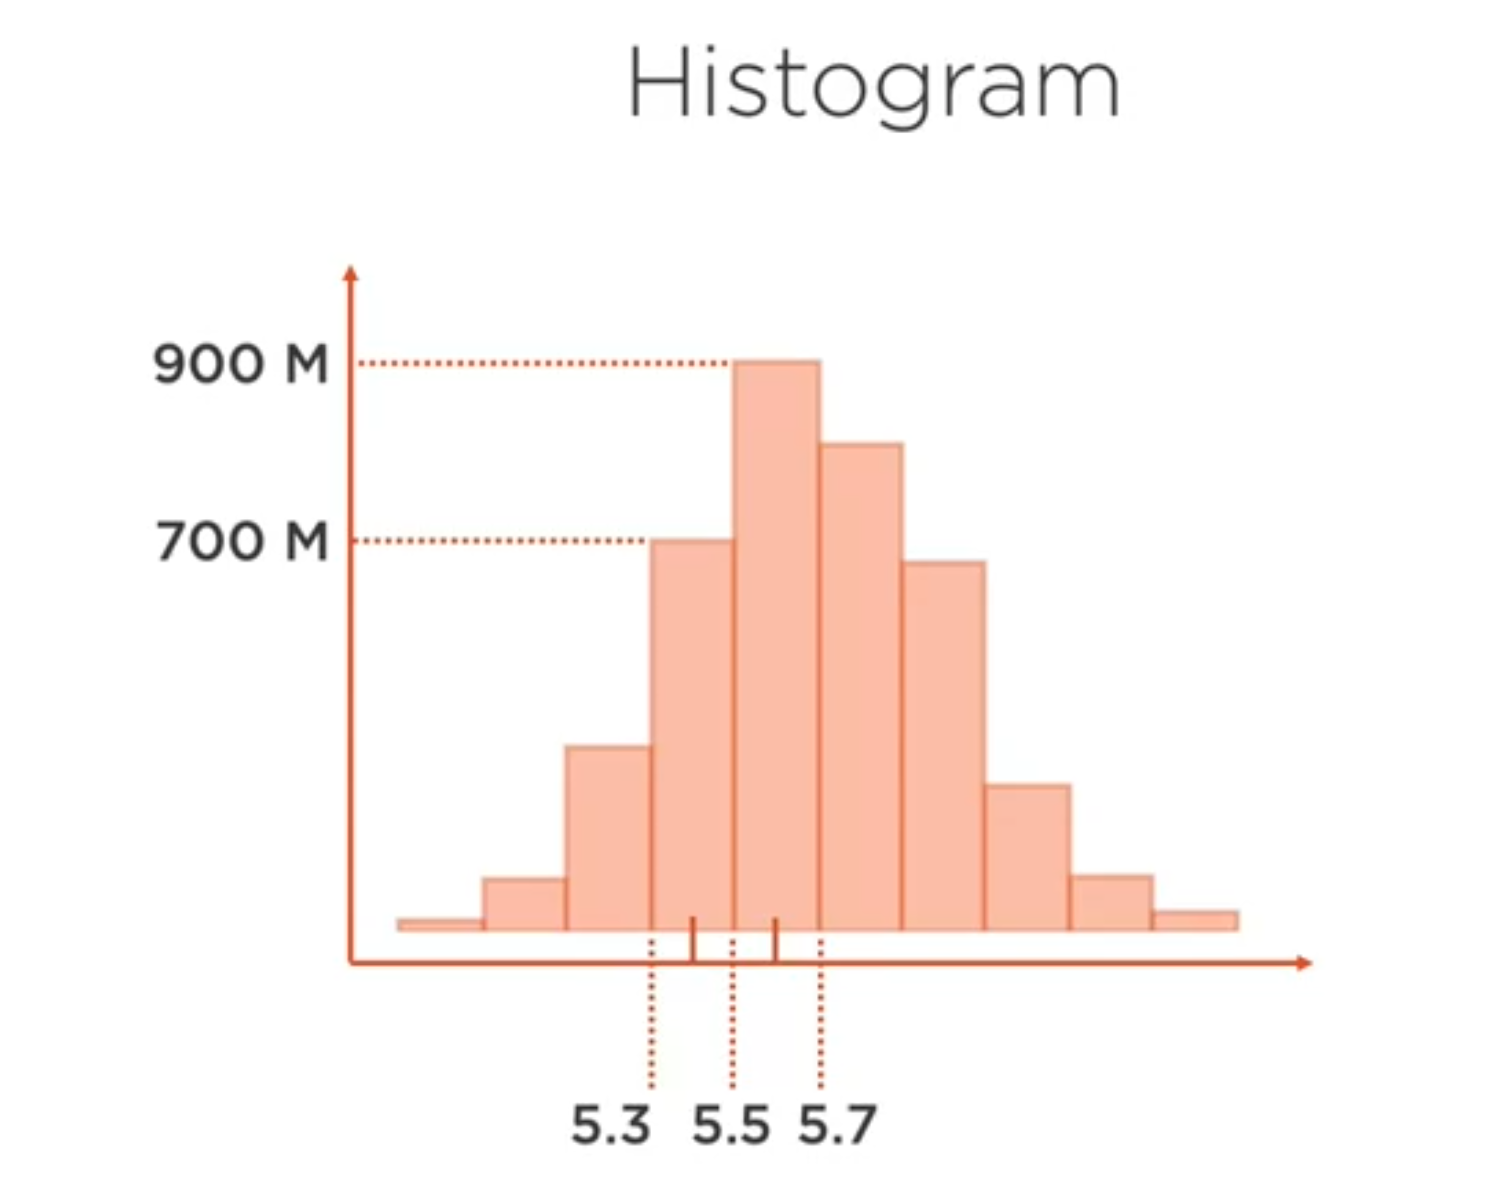

- __[Diagrama de Densidad](https://es.wikipedia.org/wiki/Funci%C3%B3n_de_densidad_de_probabilidad)__

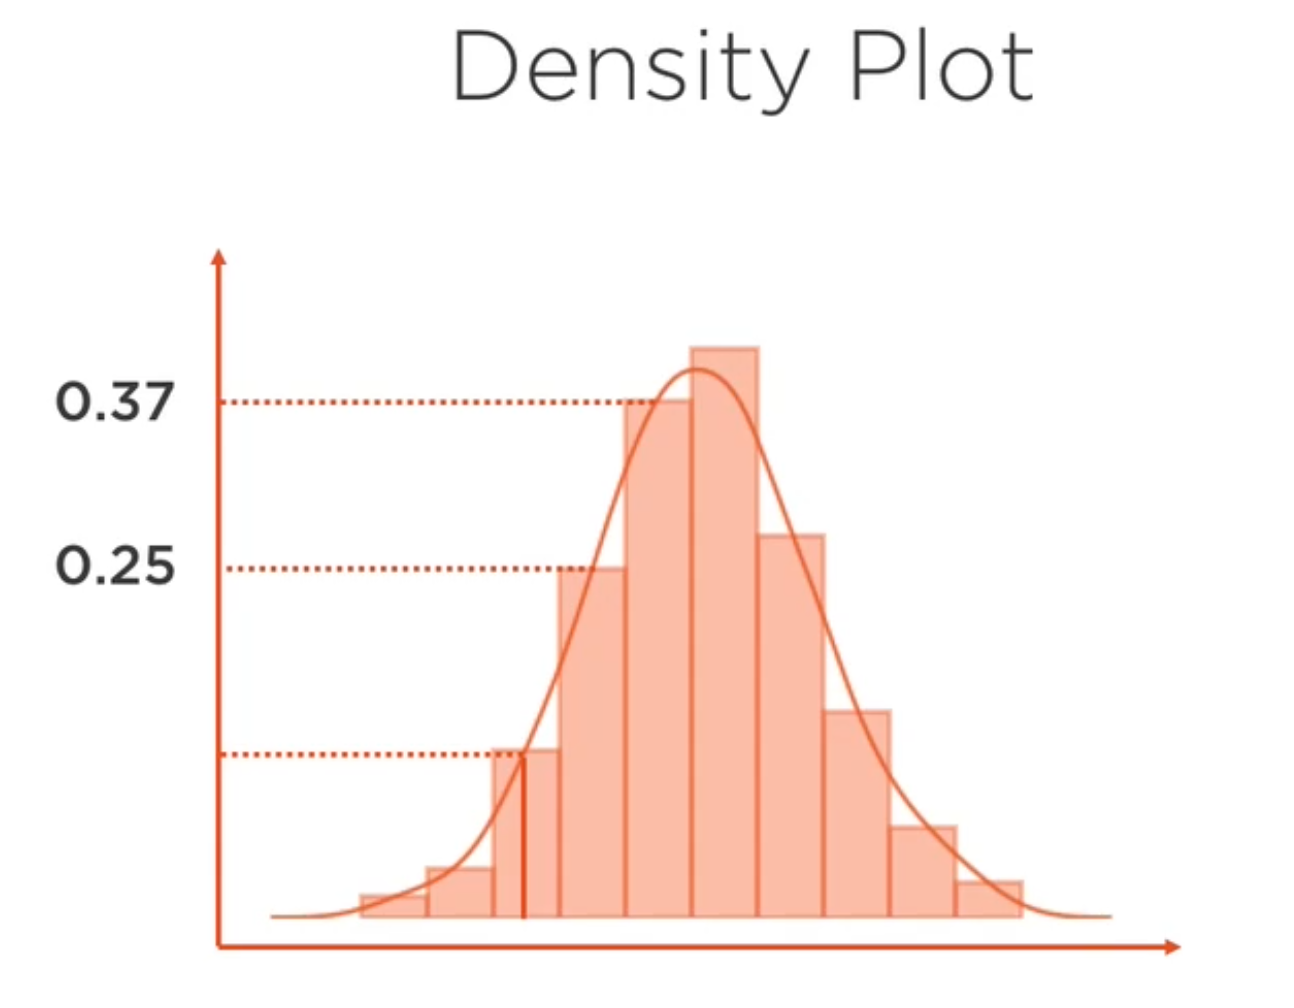

- __[Diagrama de Caja](https://es.wikipedia.org/wiki/Diagrama_de_caja)__

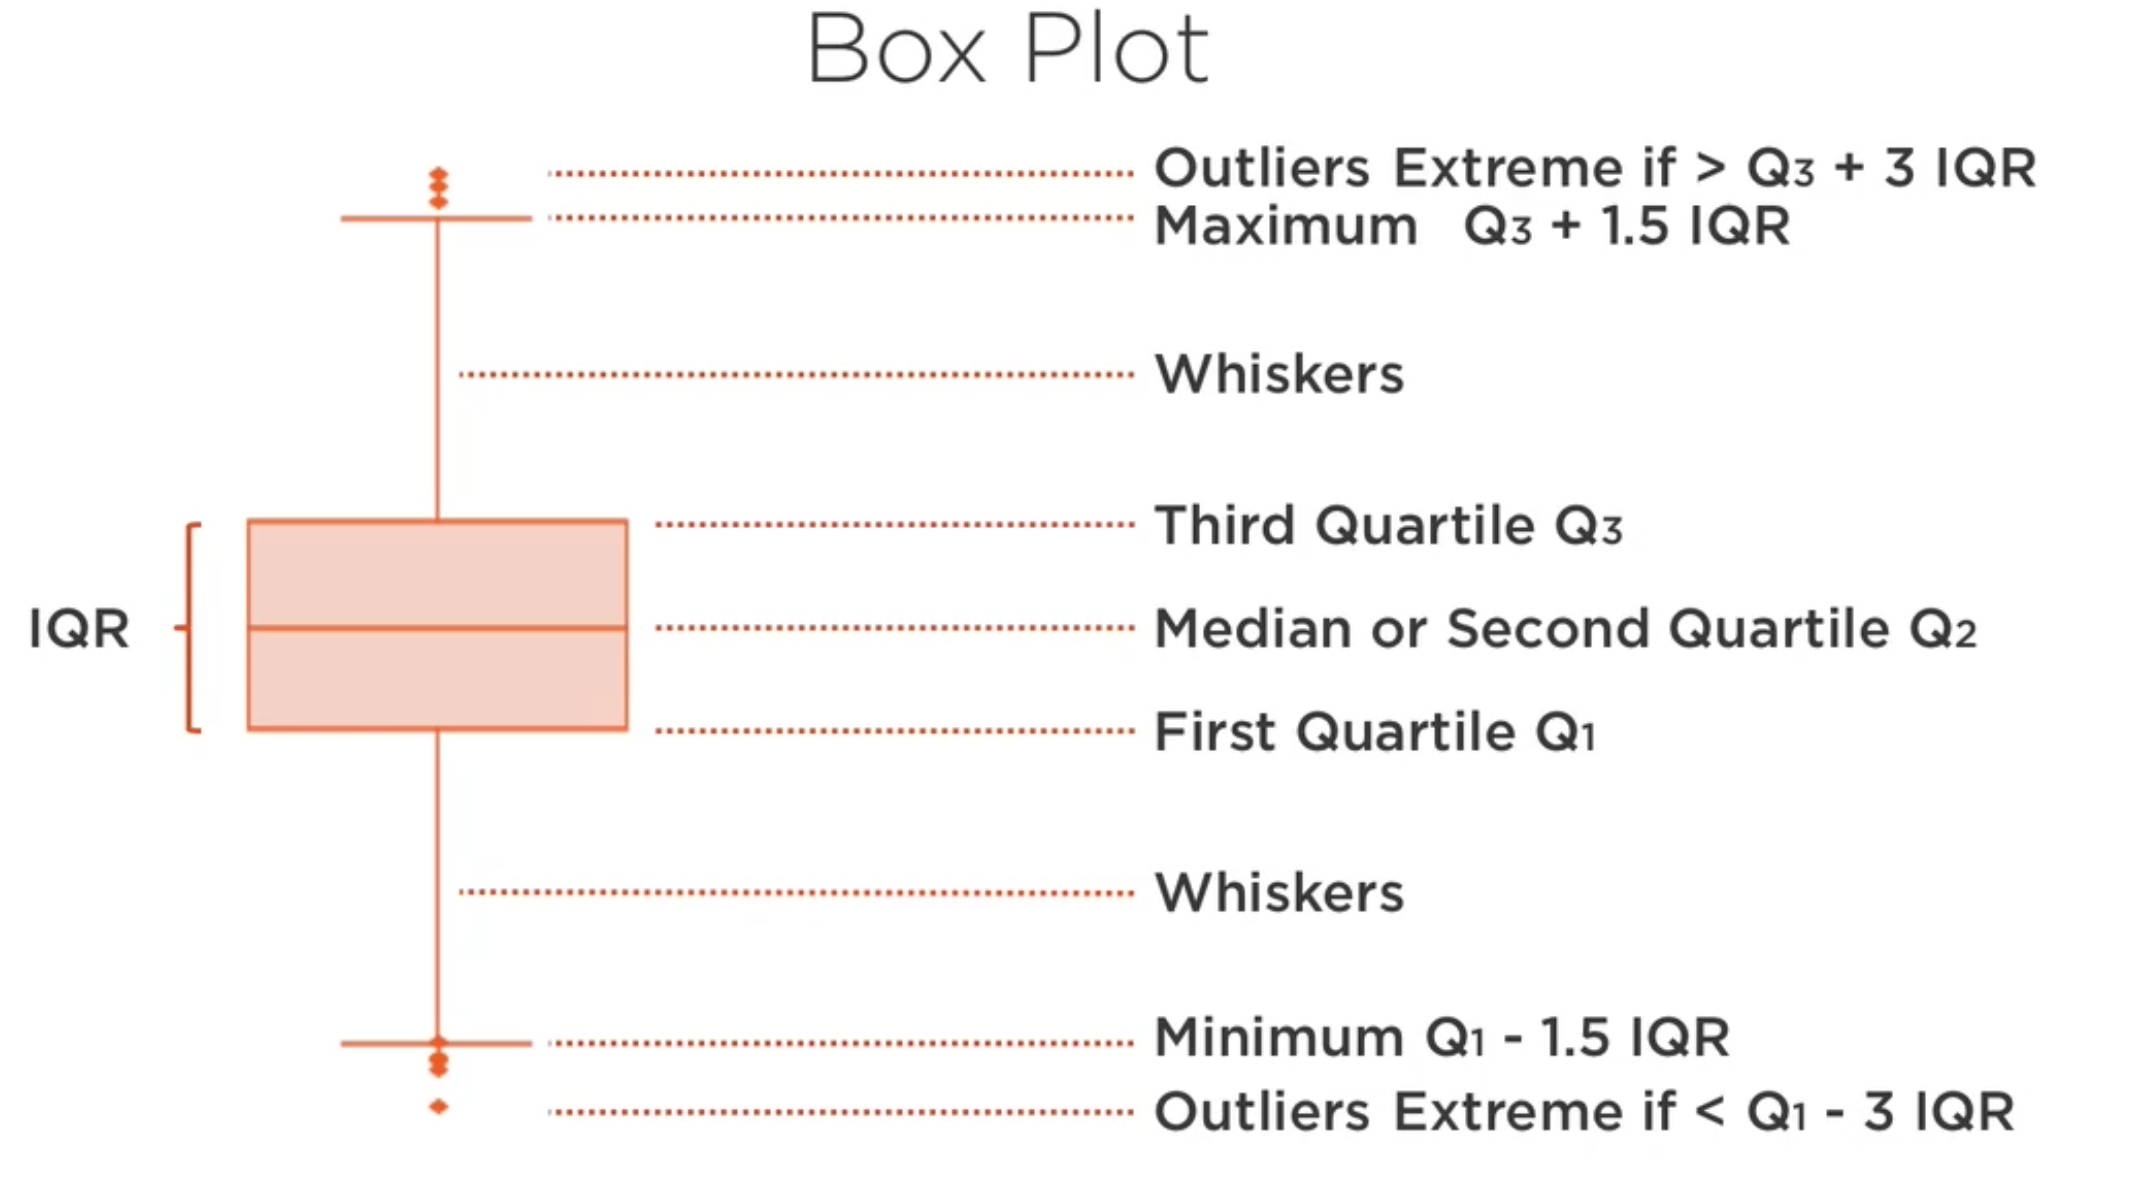

In [36]:
forestfires.get_column('temp').plot.hist()

alt.Chart(...)

<Axes: title={'center': 'Histograma Temp'}, ylabel='Frequency'>

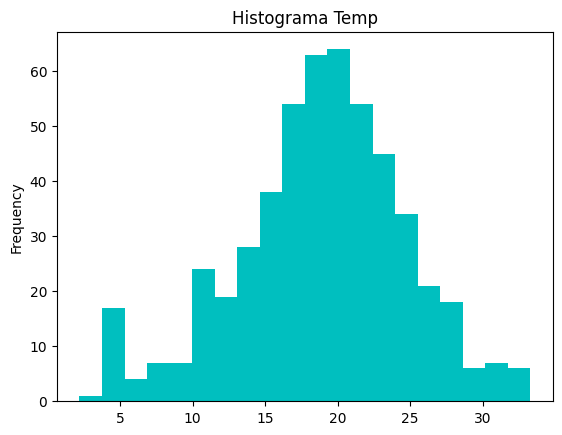

In [37]:
forestfires.to_pandas()['temp'].plot.hist(title='Histograma Temp', color='c', bins=20)

In [38]:
forestfires.get_column('temp').plot.kde()

alt.Chart(...)

<Axes: title={'center': 'Densidad Temp'}, ylabel='Density'>

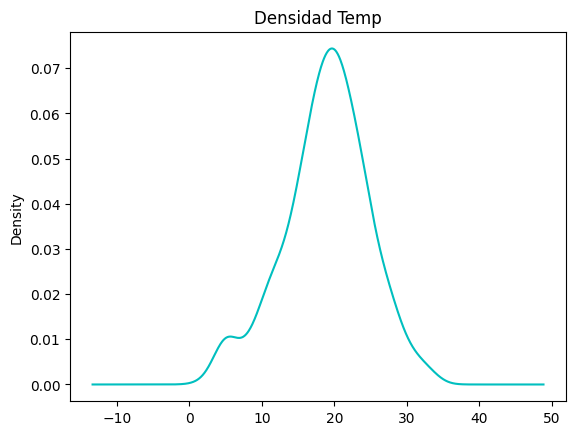

In [39]:
forestfires.to_pandas()['temp'].plot.density(title='Densidad Temp', color='c')

<Axes: title={'center': 'Box Temp'}>

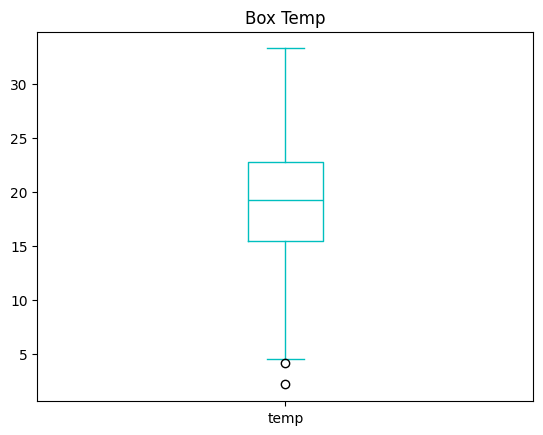

In [40]:
forestfires.to_pandas()['temp'].plot.box(title='Box Temp', color='c')

## Gráficos de comparación


- __[Gráfico de Barras](https://es.wikipedia.org/wiki/Diagrama_de_barras)__ presenta datos **cualitativos** con barras rectangulares con alturas o longitudes proporcionales a los valores que representan. (No son histogramas!!)

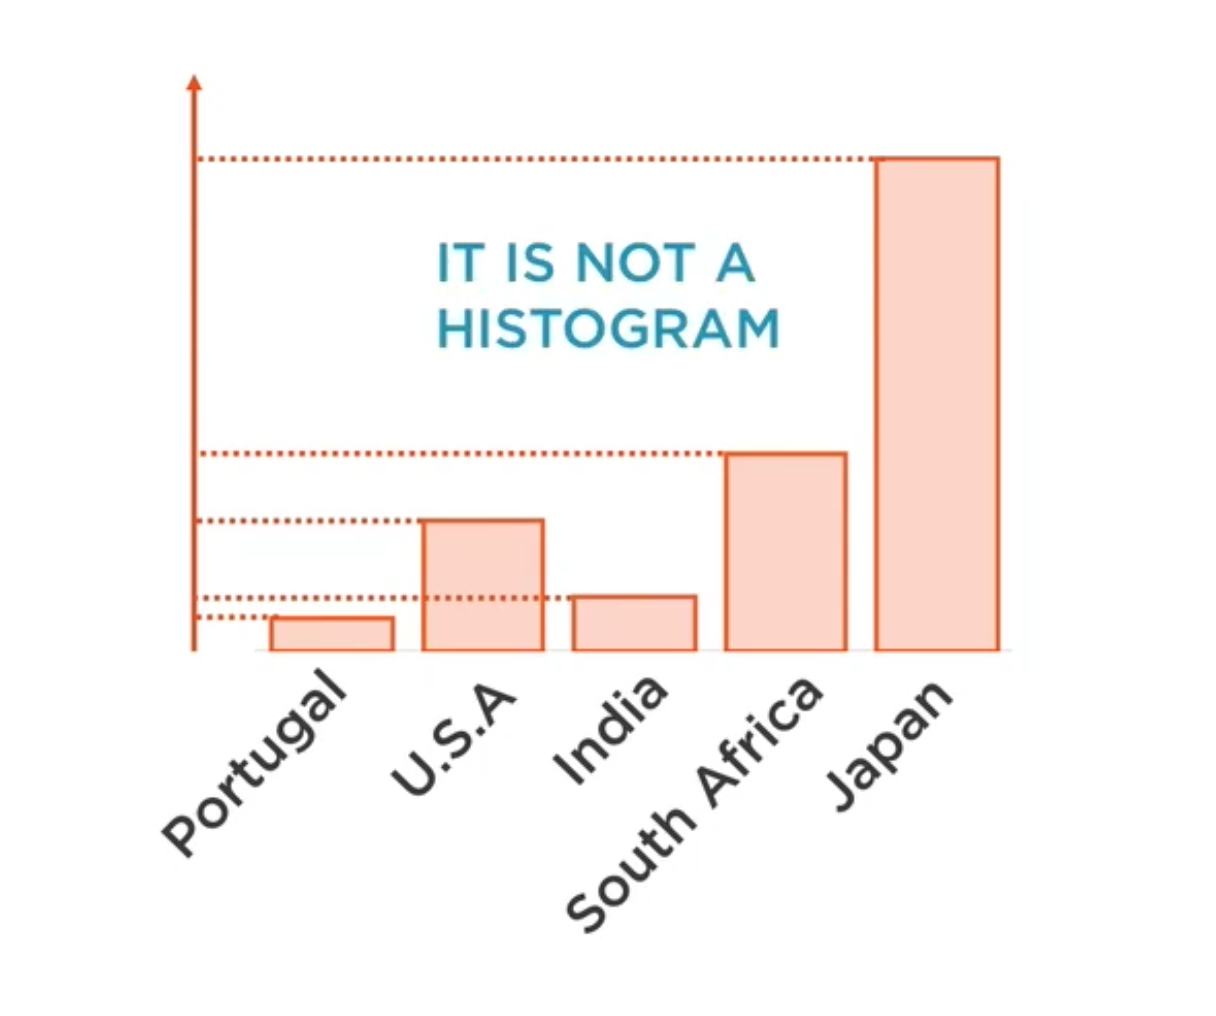

- __[Gráfico de lineas](https://en.wikipedia.org/wiki/Line_chart)__ presenta una serie de valores (marcas) conectados por líneas. Se emplean frecuentemente para visualizar tendencias a lo largo del tiempo.

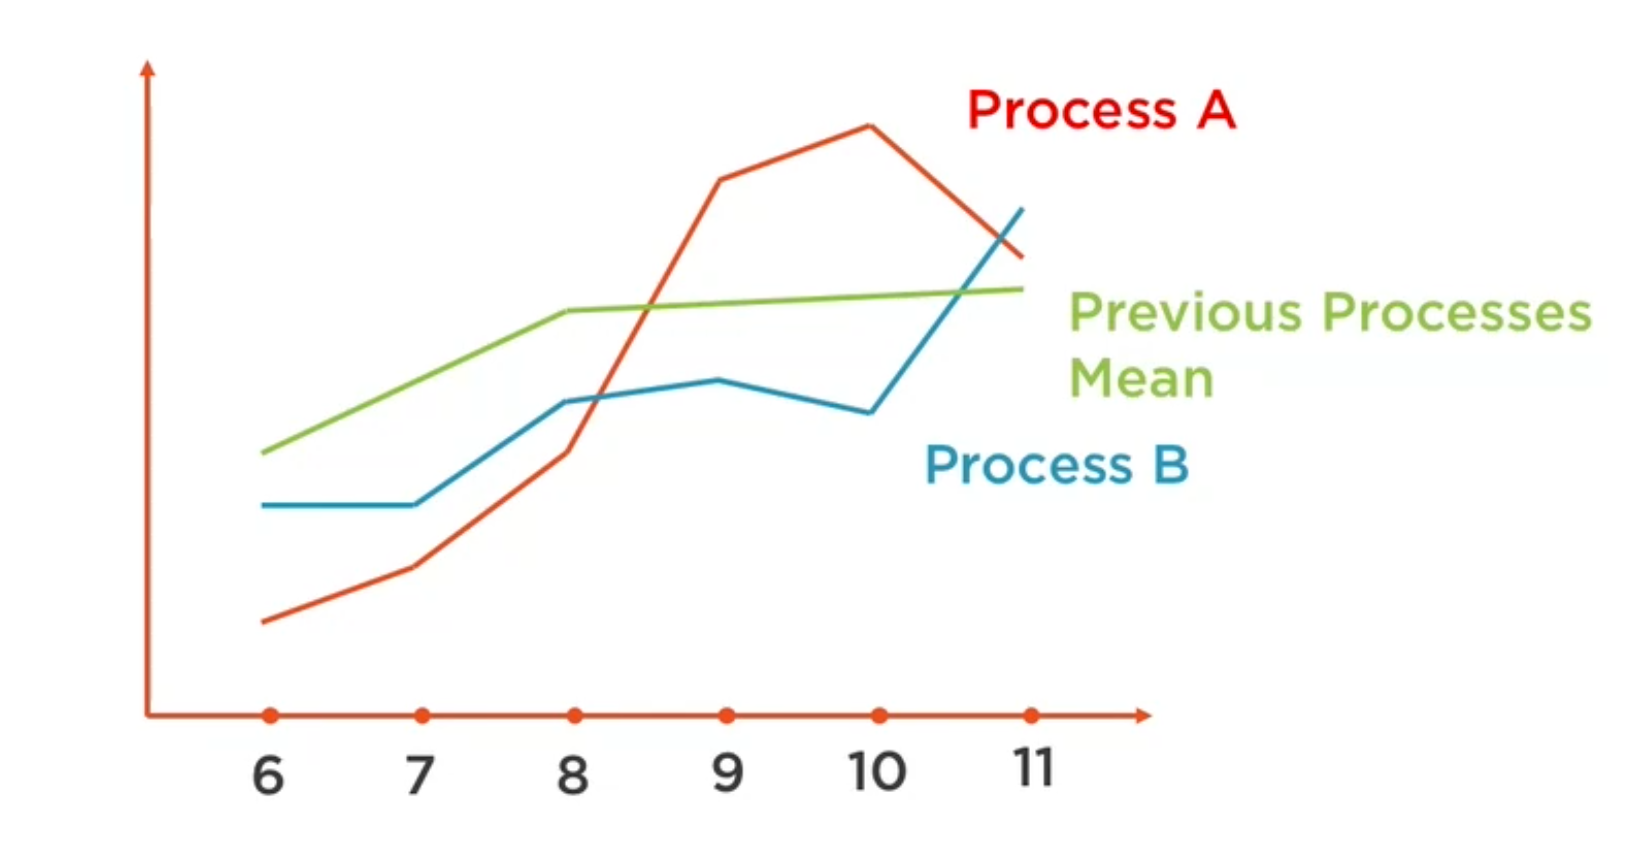

Para ambos tipos de gráficos, se recomienda aplicarlos para un número reducido de variables (~ 6)

In [41]:
ventas_por_region = pl.DataFrame(
    {'lab':['A', 'B', 'C'], 'val':[10, 30, 20]}
)

<Axes: xlabel='lab'>

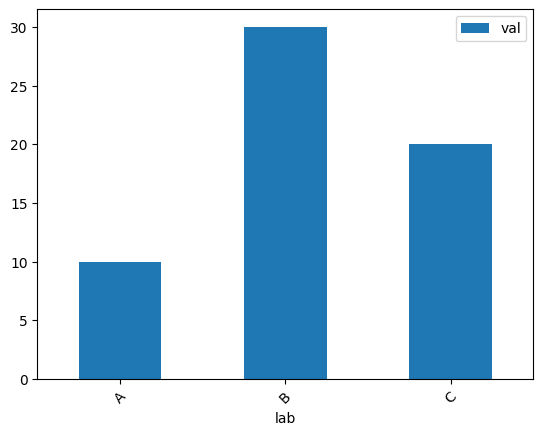

In [42]:
ventas_por_region.to_pandas().plot.bar(x='lab', y='val', rot=45)

## GroupBy


In [43]:
forestfires

X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
i64,i64,str,str,f64,f64,f64,f64,f64,i64,f64,f64,f64
7,5,"""mar""","""fri""",86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
7,4,"""oct""","""tue""",90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
7,4,"""oct""","""sat""",90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
8,6,"""mar""","""fri""",91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
8,6,"""mar""","""sun""",89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
4,3,"""aug""","""sun""",81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
2,4,"""aug""","""sun""",81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
7,4,"""aug""","""sun""",81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16


In [44]:
def month_number(month):
    if 'jan' == month:
        return 1
    elif 'feb' == month:
        return 2
    elif 'mar' == month:
        return 3
    elif 'apr' == month:
        return 4
    elif 'may' == month:
        return 5
    elif 'jun' == month:
        return 6
    elif 'jul' == month:
        return 7
    elif 'aug' == month:
        return 8
    elif 'sep' == month:
        return 9
    elif 'oct' == month:
        return 10
    elif 'nov' == month:
        return 11
    elif 'dec' == month:
        return 12
    return 0


forestfires = forestfires.with_columns(
    pl.col("month").map_elements(month_number).alias("month_number")
)


In [45]:
por_mes = forestfires.group_by("month_number")
por_mes

In [46]:
promedio_temperatura_mes = por_mes.agg(pl.col("temp").mean()).sort("month_number")
promedio_temperatura_mes

month_number,temp
i64,f64
1,5.25
2,9.635
3,13.083333
4,12.044444
5,14.65
…,…
8,21.631522
9,19.612209
10,17.093333


<Axes: xlabel='month_number'>

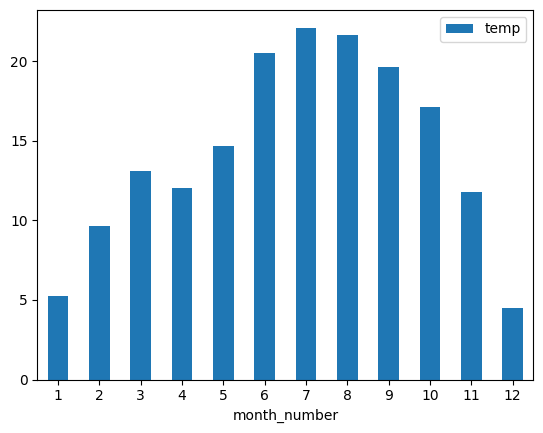

In [47]:
promedio_temperatura_mes.to_pandas().plot.bar(x='month_number', y='temp', rot=0)

<Axes: xlabel='month_number'>

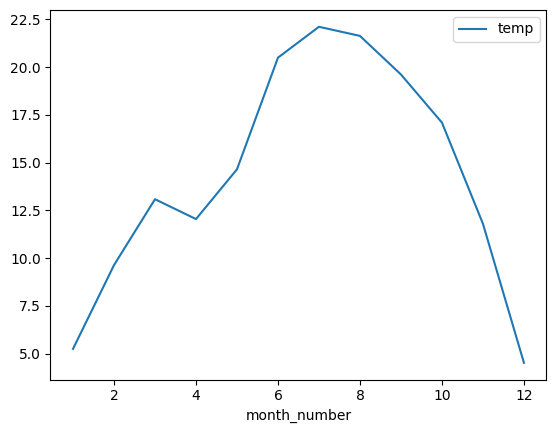

In [48]:
promedio_temperatura_mes.to_pandas().plot.line(x='month_number', y='temp', rot=0)

## Gráficos de composición

__[Panda's Plots](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)__

- __[Torta](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)__

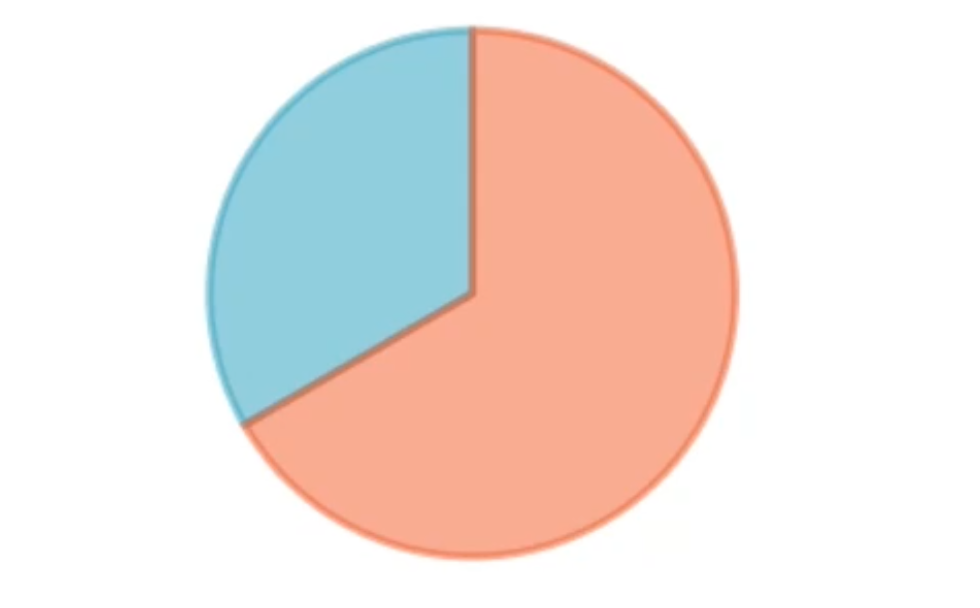

- __[Barras apiladas](https://businessq-software.com/2017/02/21/stacked-bar-chart-definition-and-examples-businessq/)__

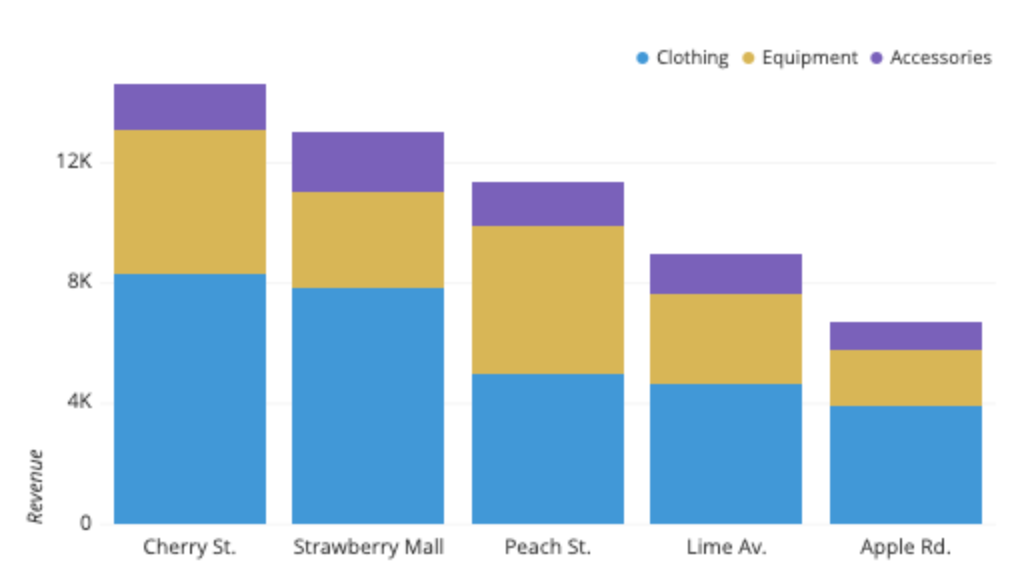


In [49]:
df = pl.DataFrame(
    {
     'masa': [0.330, 4.87 , 5.97],
    'radio': [2439.7, 6051.8, 6378.1],
     'planeta': ['Mercurio', 'Venus', 'Tierra']
    }
)
df

masa,radio,planeta
f64,f64,str
0.33,2439.7,"""Mercurio"""
4.87,6051.8,"""Venus"""
5.97,6378.1,"""Tierra"""


<Axes: ylabel='masa'>

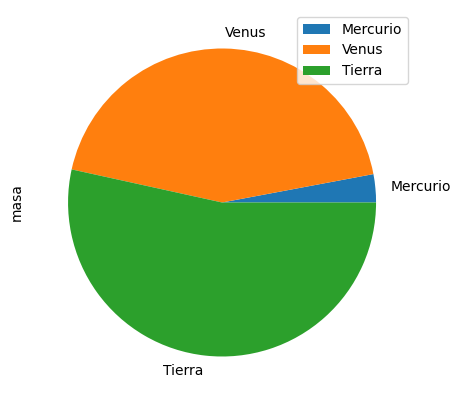

In [50]:
df.to_pandas().plot.pie(y='masa', labels=df.get_column('planeta'), figsize=(5, 5))

In [51]:
df = pl.DataFrame({'vestimenta': [8261.68, 7875.87 , 4990.23],
                   'equipamiento': [4810.34, 3126.58, 4923.48],
                   'accesorios': [1536.57, 2019.81, 1472.59],
                  'tienda': ['Cherry St', 'Strawberry Mall', 'Peach St']}
                  )
df

vestimenta,equipamiento,accesorios,tienda
f64,f64,f64,str
8261.68,4810.34,1536.57,"""Cherry St"""
7875.87,3126.58,2019.81,"""Strawberry Mall"""
4990.23,4923.48,1472.59,"""Peach St"""


<Axes: xlabel='tienda'>

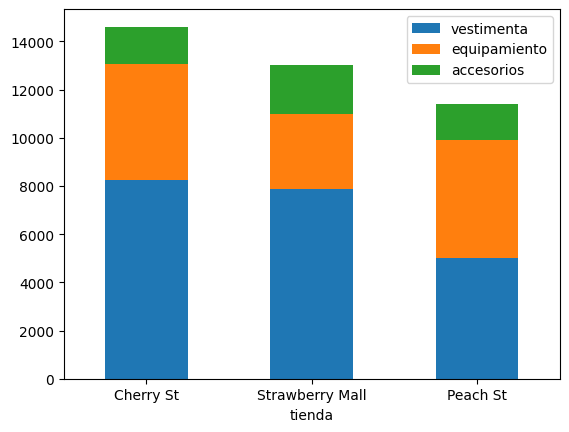

In [52]:
df.to_pandas().plot.bar(x='tienda', stacked=True, rot=0)

## Matplotlib



### ¿Qué es Matplotlib?

**Matplotlib** es una librería completa para crear visualizaciones estáticas, animadas e interactivas en Python.

#### Características principales:
- **Control de bajo nivel:** A diferencia de librerías de alto nivel, Matplotlib permite modificar prácticamente cualquier pixel del gráfico.
- **Soporte de formatos:** Permite exportar gráficos en formatos de alta calidad como PNG, PDF, SVG y EPS.
- **Ecosistema:** Es la infraestructura que utilizan `Pandas`, `Seaborn` y `Polars` (cuando se usa el backend de visualización correspondiente) para renderizar sus gráficos.

#### Conceptos Clave:
- **Figure:** Es el lienzo o ventana donde se dibuja todo.
- **Axes:** Es lo que normalmente llamamos 'el gráfico' (contiene los ejes X e Y, títulos, etc.). Una Figure puede tener múltiples Axes.

```python
import matplotlib.pyplot as plt

# Estructura básica de un gráfico
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 2, 5])
ax.set_title("Gráfico básico")
plt.show()
```

In [53]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import polars.selectors as cs

In [54]:
forestfires = pl.read_csv("forestfires.csv"
    , schema_overrides={
        "area": pl.Float64
    }
)
forestfires

X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
i64,i64,str,str,f64,f64,f64,f64,f64,i64,f64,f64,f64
7,5,"""mar""","""fri""",86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
7,4,"""oct""","""tue""",90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
7,4,"""oct""","""sat""",90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
8,6,"""mar""","""fri""",91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
8,6,"""mar""","""sun""",89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
4,3,"""aug""","""sun""",81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
2,4,"""aug""","""sun""",81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
7,4,"""aug""","""sun""",81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16


In [55]:
data_description = forestfires.select(cs.numeric()).describe()
data_description

statistic,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",517.0,517.0,517.0,517.0,517.0,517.0,517.0,517.0,517.0,517.0,517.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.669246,4.299807,90.644681,110.87234,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
"""std""",2.313778,1.2299,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
"""min""",1.0,2.0,18.7,1.1,7.9,0.0,2.2,15.0,0.4,0.0,0.0
"""25%""",3.0,4.0,90.2,68.6,437.7,6.5,15.5,33.0,2.7,0.0,0.0
"""50%""",4.0,4.0,91.6,108.3,664.2,8.4,19.3,42.0,4.0,0.0,0.52
"""75%""",7.0,5.0,92.9,142.4,713.9,10.8,22.8,53.0,4.9,0.0,6.57
"""max""",9.0,9.0,96.2,291.3,860.6,56.1,33.3,100.0,9.4,6.4,1090.84


In [56]:
forestfires.select(pl.col("temp").median()).select("temp").item(0,0)

19.3

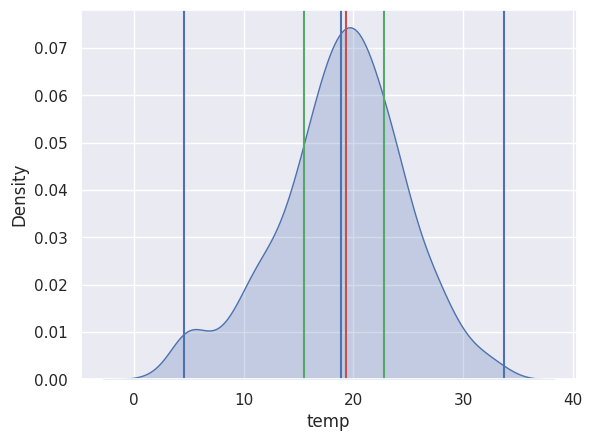

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.kdeplot(forestfires.to_pandas()['temp'], fill=True)

q1 = data_description.filter(pl.col("statistic") == "25%").select("temp").item(0,0)
q3 = data_description.filter(pl.col("statistic") == "75%").select("temp").item(0,0)
mean = forestfires.select(pl.col("temp").mean()).select("temp").item(0,0)
median = forestfires.select(pl.col("temp").median()).select("temp").item(0,0)

# agregar lineas verticales en diferentes puntos
plt.axvline(mean, 0, 1)
plt.axvline(median, 0, 1, color='r')
plt.axvline(q1, 0, 1, color='g')
plt.axvline(q3, 0, 1, color='g')

IQR = q3 - q1

upper_outliers = q3 + 1.5*IQR
lower_outliers = q1 - 1.5*IQR

plt.axvline(upper_outliers, 0, 1, color='b')
plt.axvline(lower_outliers, 0, 1, color='b')